In [4]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = last 4 digits of your Drexel ID.

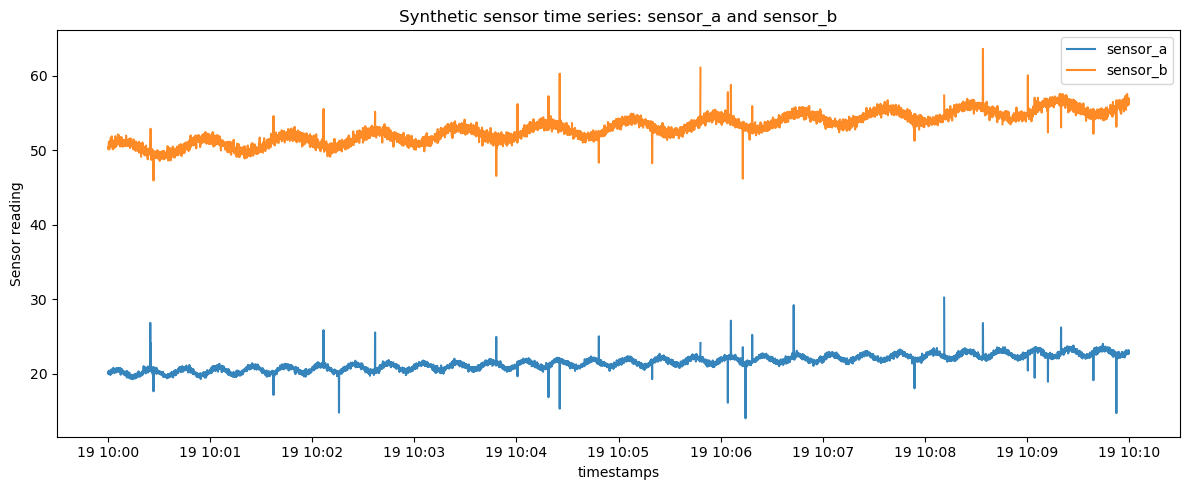

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

np.random.seed(42)
T = 600
fs = 10

t = np.arange(0, T, 1/fs)
n = t.size

start_time = datetime(2026, 4, 19, 10, 0, 0)
timestamps = [start_time + timedelta(seconds=float(sec)) for sec in t]

sensor_a = 20 + 0.5*np.sin(2*np.pi*0.05*t) + 0.005*t + 0.2*np.random.randn(n)
sensor_b = 50 + 1.0*np.sin(2*np.pi*0.02*t + 0.7) + 0.01*t + 0.4*np.random.randn(n)

num_spikes = 30
spike_idx = np.random.choice(n, num_spikes, replace=False)
sensor_a[spike_idx] += np.random.choice([+8, -8], size=num_spikes) * np.random.rand(num_spikes)
sensor_b[spike_idx] += np.random.choice([+8, -8], size=num_spikes) * np.random.rand(num_spikes)

missing_idx = np.random.choice(n, size=int(0.02*n), replace=False)
sensor_a[missing_idx] = np.nan
sensor_b[missing_idx] = np.nan

plt.figure(figsize=(12,5))
plt.plot(timestamps, sensor_a, label='sensor_a', alpha=0.9)
plt.plot(timestamps, sensor_b, label='sensor_b', alpha=0.9)
plt.xlabel('timestamps')
plt.ylabel('Sensor reading')
plt.title('Synthetic sensor time series: sensor_a and sensor_b')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.

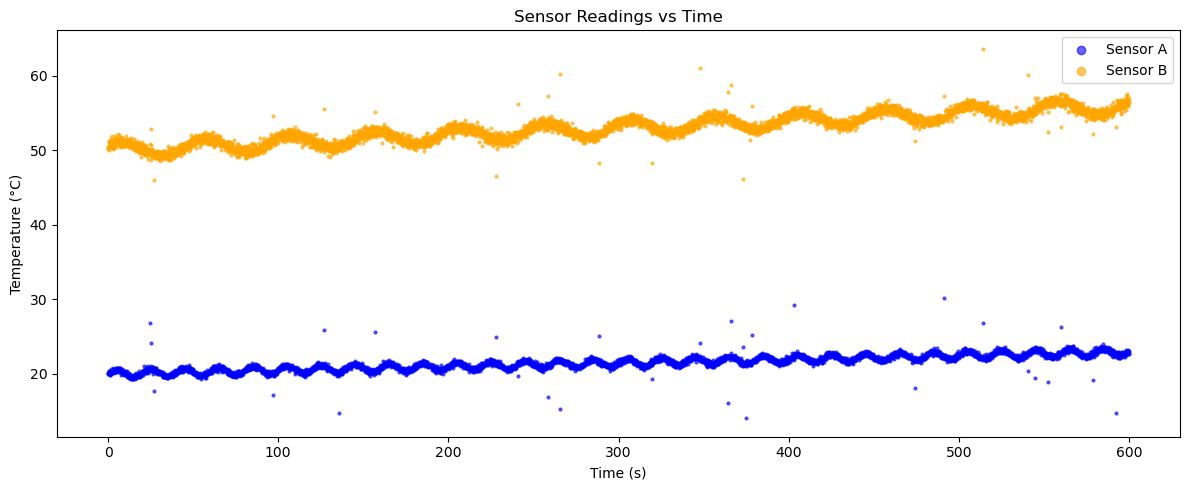

In [8]:
t_seconds = np.array([(ts - timestamps[0]).total_seconds() for ts in timestamps])

plt.figure(figsize=(12, 5))
plt.scatter(t_seconds, sensor_a, color='blue',   s=4, alpha=0.6, label='Sensor A')
plt.scatter(t_seconds, sensor_b, color='orange', s=4, alpha=0.6, label='Sensor B')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Sensor Readings vs Time')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [9]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

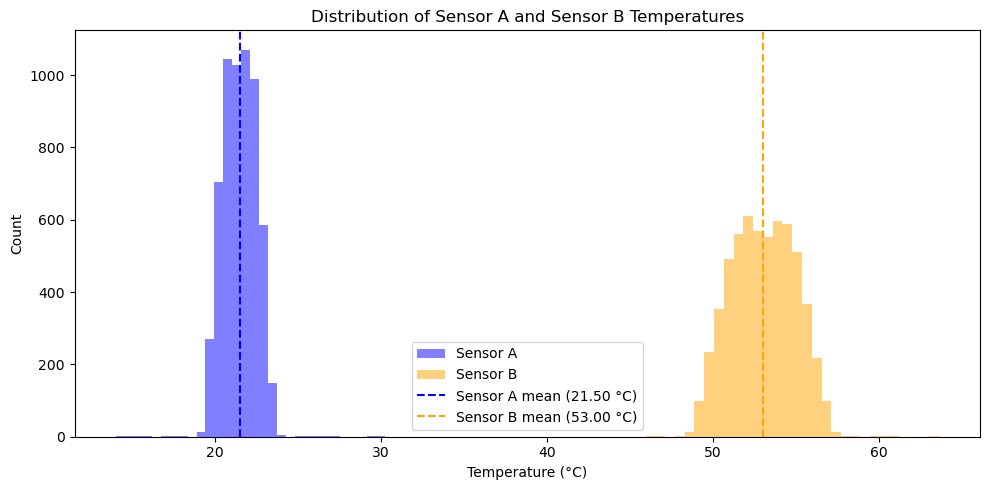

In [10]:
mean_a = np.nanmean(sensor_a)
mean_b = np.nanmean(sensor_b)

plt.figure(figsize=(10, 5))
plt.hist(sensor_a, bins=30, alpha=0.5, color='blue',   label='Sensor A')
plt.hist(sensor_b, bins=30, alpha=0.5, color='orange', label='Sensor B')
plt.axvline(mean_a, color='blue',   linestyle='--', linewidth=1.5, label=f'Sensor A mean ({mean_a:.2f} °C)')
plt.axvline(mean_b, color='orange', linestyle='--', linewidth=1.5, label=f'Sensor B mean ({mean_b:.2f} °C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Distribution of Sensor A and Sensor B Temperatures')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

C:\Users\furqa\AppData\Local\Temp\ipykernel_33004\1903833208.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


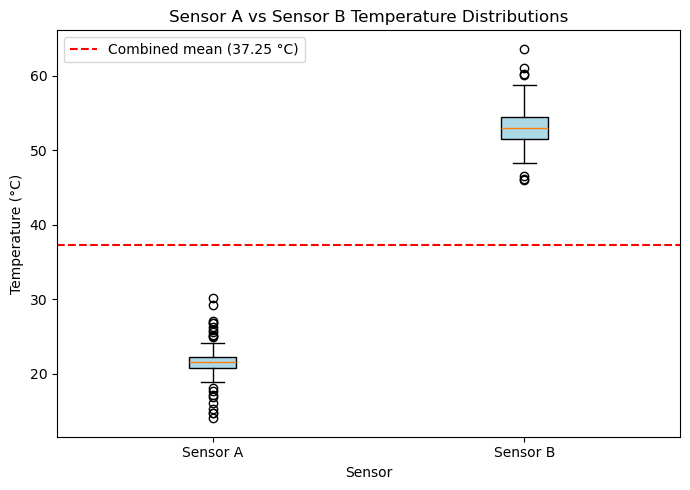

In [13]:
overall_mean = np.nanmean(np.concatenate([sensor_a, sensor_b]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [sensor_a[~np.isnan(sensor_a)], sensor_b[~np.isnan(sensor_b)]],
    labels=['Sensor A', 'Sensor B'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
ax.axhline(overall_mean, color='red', linestyle='--', linewidth=1.5,
           label=f'Combined mean ({overall_mean:.2f} °C)')
ax.set_xlabel('Sensor')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Sensor A vs Sensor B Temperature Distributions')
ax.legend()
plt.tight_layout()
plt.show()